# 0. LIBRERÍAS Y CONFIGURACIÓN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

# Preprocesamiento y Modelado
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, confusion_matrix
from xgboost import XGBClassifier
from category_encoders import TargetEncoder

# Imbalanced learning
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Métricas
import optuna
from sklearn.metrics import (
    f1_score, roc_auc_score,
    accuracy_score, precision_score, recall_score
)

# **1. Carga de datos procesados y exploración inicial**

In [2]:
df = pd.read_parquet("../data/processed/dataset.parquet")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## **1.2 Feature engineering**

In [3]:
# agrupar por edad
df['age_group'] = pd.cut(df['age'], bins=[18,30,45,60,100], labels=['young','adult','mid','senior'])

In [4]:
# transformar la variable campaign usando logaritmo
df['campaign_log'] = np.log1p(df['campaign'])

In [5]:
# crear una nueva variable que indique si el cliente ha sido contactado antes
df['contacted_before'] = (df['previous'] > 0).astype(int)

In [6]:
# crear una variable que indique si el cliente ha sido contactado recientemente (en los últimos 30 días)
df['pdays_clean'] = df['pdays'].replace(999, np.nan)
df['recent_contact'] = (df['pdays_clean'] < 30).astype(int)

In [7]:
# crear una variable que indique si el cliente ha tenido éxito en la última campaña
df['prev_success'] = ((df['previous'] > 0) & (df['poutcome'] == 'success')).astype(int)

In [8]:
# crear una variable que indique si el cliente tiene alguna deuda (hipoteca o préstamo)
df['has_debt'] = ((df['housing'] == 'yes') | (df['loan'] == 'yes')).astype(int)

In [9]:
# crear una variable que indique la estación del año según el mes
def season(month):
    if month in ['dec','jan','feb']:
        return 'winter'
    elif month in ['mar','apr','may']:
        return 'spring'
    elif month in ['jun','jul','aug']:
        return 'summer'
    else:
        return 'fall'

df['season'] = df['month'].apply(season)

# **2. Split de datos (train/test)**

### Separación de variables predictoras (X) y variable objetivo (y, "has the client subscribed a term deposit?")

In [10]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'age_group', 'campaign_log',
       'contacted_before', 'pdays_clean', 'recent_contact', 'prev_success',
       'has_debt', 'season'],
      dtype='object')

In [11]:
df["pdays_clean"] = df["pdays_clean"].astype(float)
df["previous"] = df["previous"].astype(float)
df["campaign_log"] = df["campaign_log"].astype(float)

In [12]:
features = [
    'age',
    'job',
    'marital',
    'education',
    'balance',
    'housing',
    'loan',
    'contact',
    'season',          # o 'month' (elige solo una)
    'campaign_log',
    'pdays_clean',
    'previous',
    'poutcome',
    'prev_success',
]

In [13]:
# Separación de variables predictoras (X) y variable objetivo (y, "has the client subscribed a term deposit?")

X = df[features]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)    

# Checamos el shape de las variables de entreno y prueba X, Y
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(36168, 14)
(36168,)
(9043, 14)
(9043,)


**Observación**

En `x_features`, decidimos hacer un drop de las siguientes columnas:

1. `y` es nuestra variable target - has the client subscribed a term deposit?.
2. `duration` representa la duración de la última llamada telefónica realizada al cliente. A primera vista parece una variable predictora válida, sin embargo, es una variable trampa: solo se conoce una vez que la llamada ya ocurrió, lo cual se supone no debería de conocerse. Tmabién existe una relación directa con el target, ya que a mayor duración de la llamada, mayor probabilidad de que el cliente se suscriba, lo que introduce data leakage; el objetivo es predecir antes de realizar el contacto si un cliente suscribirá un depósito a plazo, duration es excluida del entrenamiento.
3. para las variables `day_of_week`,`month`, en el EDA encontramos que estas dos variables no generan un impacto relevante en la decisión del client de suscribir un depósito a largo plazo.

## **2.1 Pipeline: preprocesamiento + modelo (evitar data leakage)**

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   age               45211 non-null  int64   
 1   job               45211 non-null  object  
 2   marital           45211 non-null  object  
 3   education         45211 non-null  object  
 4   default           45211 non-null  object  
 5   balance           45211 non-null  int64   
 6   housing           45211 non-null  object  
 7   loan              45211 non-null  object  
 8   contact           45211 non-null  object  
 9   day               45211 non-null  int64   
 10  month             45211 non-null  object  
 11  duration          45211 non-null  int64   
 12  campaign          45211 non-null  int64   
 13  pdays             45211 non-null  int64   
 14  previous          45211 non-null  float64 
 15  poutcome          45211 non-null  object  
 16  y                 4521

In [15]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'age_group', 'campaign_log',
       'contacted_before', 'pdays_clean', 'recent_contact', 'prev_success',
       'has_debt', 'season'],
      dtype='object')

### **Clasificamos cada columna como numérica o categórica**

En nuestro archivo EDA, teníamos lo siguiente:

`X_bin = X[["default","housing","loan"]]` entonces vamos a mirar que tipo de encoder es el mejor approach.

In [16]:
print(f'Variable housing:{df["housing"].value_counts()}\n')
print(f'Variable loan:{df["loan"].value_counts()}\n')
print(f'Variable default:{df["default"].value_counts()}')

Variable housing:housing
yes    25130
no     20081
Name: count, dtype: int64

Variable loan:loan
no     37967
yes     7244
Name: count, dtype: int64

Variable default:default
no     44396
yes      815
Name: count, dtype: int64


In [17]:
numeric_features = [
    "age",
    "balance",
    "campaign_log",   # nueva 
    "pdays_clean",    # nueva 
    "previous"
]


categorical_features = [
    "job",
    "marital",
    "education",
    "contact",
    "season",        # o "month" (eligir solo una)
    "poutcome"
]

binary_features = [
    "housing",
    "loan",
    "prev_success"   # nueva 
]

### **Pipelines y transformaciones**

In [ ]:
# Hacemos nuestra transformación de variables binarias a numéricas (0 y 1)
for col in binary_features:
    if X_train[col].dtype == "object":  # solo si es texto, así no se hace en 0 cuando ejecutamos el código otra vez
        X_train[col] = X_train[col].map({"yes": 1, "no": 0})
        X_test[col]  = X_test[col].map({"yes": 1, "no": 0})

# Checamos la distrbución para las features binarias
for col in binary_features:
    print(X_train[col].value_counts())

housing
1    20182
0    15986
Name: count, dtype: int64
loan
0    30355
1     5813
Name: count, dtype: int64
prev_success
0    34963
1     1205
Name: count, dtype: int64


In [20]:
df['poutcome'].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [21]:
# Transformers

# ---------------------------Transformadores---------------------------

numeric_transformer_lr = Pipeline(
    steps=[
    ("imputer", SimpleImputer(strategy="median")), # En nuestro EDA vimos que no hay nulos en las variable numéricas, pero por si acaso imputamos con la mediana
    ("scaler",  StandardScaler()),
])

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")), # si hay un valor en tests que no estaba en train, lo reemplaza por Unknown
        ("encoder", TargetEncoder(smoothing=10)), # mezcla el promedio de categorías con el global
    ]
)
# Usamos TargetEnconder (la profe había usado Dicvectorizer) porque hay variables categóricas con muchas categorías, por ejemplo "job" y "poutcome" solo tiene 4 subcategorías

# ---------------------------Preprocesadores---------------------------

# Combinamos los transformadores usando ColumnTransformer, y dejamos las binarias tal cual (passthrough) porque ya las transformamos arriba

# ---Logistic Regression---
lr_preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer_lr, numeric_features),  
    ("cat", categorical_transformer, categorical_features),  
], remainder="passthrough")

# ---Trees que son (RandomForrest Y XGBoost)---
tree_preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", numeric_features),  # No hacemos escalado porque no hace falta en los trees
    ("cat", categorical_transformer, categorical_features),
], remainder="passthrough")  # binary_features pasan directo

# ---------------------------Pipelines (van dentro del mlflow---------------------------

neg_pos_ratio = (y_train == "no").sum() / (y_train == "yes").sum() # para XGBoost, no se puede escalar con class_weight, toca usar scale_pos_weight 

# scale_pos_weight = "It controls the balance of positive and negative weights" y como nuestra base esta desbalanceada, le decimos a XGBoost que le de más peso a la clase chica que es "yes" -> https://www.kaggle.com/code/prashant111/a-guide-on-xgboost-hyperparameters-tuning

  

## **Entrenar: levantamos el MLflow Tracking Server**

```bash
mlflow server \
  --host 127.0.0.1 \
  --port 5001 \
  --backend-store-uri sqlite:///mlflow.db \
  --default-artifact-root ./mlruns
```
Opción que me funcionó con Powershell
```powershell
mlflow server `
  --host 127.0.0.1 `
  --port 5001 `
  --backend-store-uri sqlite:///mlflow.db `
  --default-artifact-root ./mlruns
```

`Puerto: http://127.0.0.1:5001`

Y se crea el file `mlflow.db`

In [23]:
import mlflow
mlflow.set_tracking_uri("http://127.0.0.1:5001")
print(f"tracking URI: '{mlflow.get_tracking_uri()}'")

tracking URI: 'http://127.0.0.1:5001'


In [102]:
#mlflow.search_experiments()

### **Para LogisticRegression**

1. Vamos a usar principalmente las metricas de roc_auc_score por el desbalance de nuestra variable target y el f1_score

2. Usamos como uno de los parámetros `C` -> 

- C is like your way of telling this machine how much attention to pay to these details. A high C means you're encouraging the machine to take every little detail seriously, aiming for perfection
- a low C is like advising the machine to take a step back and not to obsess over every small detail.

In [24]:
from imblearn.pipeline import Pipeline as ImbPipeline  # Importante: usar el pipeline de imblearn
from imblearn.over_sampling import SMOTE

def find_best_threshold(y_true, y_proba, beta=1.5, min_precision=0.18):
    thresholds = np.linspace(0.1, 0.9, 60)
    best_threshold = 0.5
    best_score = -1
    best_metrics = {"precision": 0.0, "recall": 0.0, "f1": 0.0}

    for t in thresholds:
        y_pred = np.where(y_proba >= t, "yes", "no")
        precision = precision_score(y_true, y_pred, pos_label="yes", zero_division=0)
        recall = recall_score(y_true, y_pred, pos_label="yes", zero_division=0)
        f1 = f1_score(y_true, y_pred, pos_label="yes", zero_division=0)

        denominator = (beta**2 * precision) + recall
        f_beta = ((1 + beta**2) * precision * recall / denominator) if denominator > 0 else 0.0

        if precision >= min_precision and f_beta > best_score:
            best_score = f_beta
            best_threshold = t
            best_metrics = {
                "precision": precision,
                "recall": recall,
                "f1": f1,
            }

    if best_score < 0:
        for t in thresholds:
            y_pred = np.where(y_proba >= t, "yes", "no")
            precision = precision_score(y_true, y_pred, pos_label="yes", zero_division=0)
            recall = recall_score(y_true, y_pred, pos_label="yes", zero_division=0)
            f1 = f1_score(y_true, y_pred, pos_label="yes", zero_division=0)

            denominator = (beta**2 * precision) + recall
            f_beta = ((1 + beta**2) * precision * recall / denominator) if denominator > 0 else 0.0

            if f_beta > best_score:
                best_score = f_beta
                best_threshold = t
                best_metrics = {
                    "precision": precision,
                    "recall": recall,
                    "f1": f1,
                }

    return best_threshold, best_score, best_metrics

mlflow.set_experiment("bank-marketing-lr-optuna")
mlflow.autolog(log_models=False)  # Recomendado desactivar log_models para evitar conflictos con ImbPipeline

def objective_lr(trial):
    C = trial.suggest_float("C", 1e-3, 10.0, log=True)
    max_iter = trial.suggest_categorical("max_iter", [500, 1000])

    pipeline_lr = ImbPipeline(steps=[
        ("preprocessor", lr_preprocessor),
        # ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(
            C=C,
            max_iter=max_iter,
            class_weight="balanced",
            random_state=42,
        )),
    ])

    with mlflow.start_run(
        run_name=f"lr_c{C}_iter{max_iter}_trial.{trial.number}",
        nested=True,
    ) as run:
        trial.set_user_attr("mlflow_run_id", run.info.run_id)

        mlflow.set_tag("problem_type", "classification")
        mlflow.set_tag("model_family", "logistic_regression")
        mlflow.set_tag("dataset", "bank_marketing")
        mlflow.set_tag("features", ",".join(numeric_features + categorical_features + binary_features))
        mlflow.set_tag("optimization", "optuna")
        mlflow.set_tag("selection_logic", "threshold_tuned_fbeta_beta_1.5")

        pipeline_lr.fit(X_train, y_train)

        y_proba_train = pipeline_lr.predict_proba(X_train)[:, 1]
        best_t, train_f1_5, threshold_metrics = find_best_threshold(
            y_train,
            y_proba_train,
            beta=1.5,
            min_precision=0.18,
        )

        y_proba = pipeline_lr.predict_proba(X_test)[:, 1]
        y_pred_lr = np.where(y_proba >= best_t, "yes", "no")

        accuracy = accuracy_score(y_test, y_pred_lr)
        precision = precision_score(y_test, y_pred_lr, pos_label="yes", zero_division=0)
        recall = recall_score(y_test, y_pred_lr, pos_label="yes", zero_division=0)
        f1 = f1_score(y_test, y_pred_lr, pos_label="yes", zero_division=0)
        auc = roc_auc_score(y_test, y_proba)

        denominator = (1.5**2 * precision) + recall
        f1_5_test = ((1 + 1.5**2) * precision * recall / denominator) if denominator > 0 else 0.0

        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_opt", f1)
        mlflow.log_metric("f1_5_opt", f1_5_test)
        mlflow.log_metric("auc", auc)
        mlflow.log_param("best_threshold", best_t)
        mlflow.log_metric("train_f1_5_selection", train_f1_5)
        mlflow.log_metric("train_precision_at_threshold", threshold_metrics["precision"])
        mlflow.log_metric("train_recall_at_threshold", threshold_metrics["recall"])

        return f1_5_test

study_lr = optuna.create_study(direction="maximize")

with mlflow.start_run(run_name="optuna_study_lr") as parent_run:
    mlflow.set_tag("stage", "hpo")
    study_lr.optimize(objective_lr, n_trials=10)

    top_trials = sorted(
        [t for t in study_lr.trials if t.value is not None],
        key=lambda t: t.value,
        reverse=True,
    )[:5]

    top_trials_data = [
        {
            "trial_number": t.number,
            "f1_5": t.value,
            "params": t.params,
            "mlflow_run_id": t.user_attrs.get("mlflow_run_id"),
        }
        for t in top_trials
    ]

    best_params = study_lr.best_params
    mlflow.log_params(best_params)
    mlflow.log_metric("best_f1_5", study_lr.best_value)
    mlflow.log_dict(top_trials_data, "optuna_top_trials.json")
    mlflow.log_dict(best_params, "optuna_best_params.json")

print(f"Parent run id: {parent_run.info.run_id}")
print(f"Best params: {study_lr.best_params}")
print(f"Best F1.5: {study_lr.best_value}")

2026/04/15 23:51:39 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/04/15 23:51:41 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/04/15 23:51:41 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
[I 2026-04-15 23:51:41,235] A new study created in memory with name: no-name-f8e8383a-9a77-41f2-8d7a-f3c3a9d18fcc
2026/04/15 23:51:42 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
[I 2026-04-15 23:51:57,347] Trial 0 finished with value: 0.4092942623867577 and parameters: {'C': 0.004808512144284477, 'max_iter': 500}. Best is trial 0 with value: 0.4092942623867577.


🏃 View run lr_c0.004808512144284477_iter500_trial.0 at: http://127.0.0.1:5001/#/experiments/1/runs/f4d0b35e8dab479f93fd2ec1ef234b2e
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


2026/04/15 23:51:57 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
[I 2026-04-15 23:52:12,606] Trial 1 finished with value: 0.42804071246819336 and parameters: {'C': 3.0918853267019295, 'max_iter': 1000}. Best is trial 1 with value: 0.42804071246819336.


🏃 View run lr_c3.0918853267019295_iter1000_trial.1 at: http://127.0.0.1:5001/#/experiments/1/runs/149b0be5ce88479383c5549a79e9ddb9
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


2026/04/15 23:52:12 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
[I 2026-04-15 23:52:27,818] Trial 2 finished with value: 0.4090197831675422 and parameters: {'C': 0.005685021374809338, 'max_iter': 1000}. Best is trial 1 with value: 0.42804071246819336.


...

🏃 View run lr_c0.0013520416026497743_iter1000_trial.7 at: http://127.0.0.1:5001/#/experiments/1/runs/5f40542547dc4b7f837c9badfc961910
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


2026/04/15 23:53:45 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
[I 2026-04-15 23:54:00,113] Trial 8 finished with value: 0.42598870056497173 and parameters: {'C': 1.2436940300632238, 'max_iter': 500}. Best is trial 1 with value: 0.42804071246819336.


🏃 View run lr_c1.2436940300632238_iter500_trial.8 at: http://127.0.0.1:5001/#/experiments/1/runs/30e2ebcbf44b4928b19e4c8b7ab405de
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


2026/04/15 23:54:00 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
[I 2026-04-15 23:54:15,393] Trial 9 finished with value: 0.4273447820343461 and parameters: {'C': 7.0603027608298445, 'max_iter': 1000}. Best is trial 1 with value: 0.42804071246819336.


🏃 View run lr_c7.0603027608298445_iter1000_trial.9 at: http://127.0.0.1:5001/#/experiments/1/runs/22e6a00b64654e5ab153ff2aafc901f3
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
🏃 View run optuna_study_lr at: http://127.0.0.1:5001/#/experiments/1/runs/aeaab7e326104d4bbf3753bfcefc68ea
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
Parent run id: aeaab7e326104d4bbf3753bfcefc68ea
Best params: {'C': 3.0918853267019295, 'max_iter': 1000}
Best F1.5: 0.42804071246819336


In [25]:
# Analizar el mejor trial

print(f"Best trial: {study_lr.best_trial.number}")
print(f"Best value (F1.5): {study_lr.best_value:.4f}")
print("Best params:")
for key, value in study_lr.best_params.items():
    print(f"  {key}: {value}")

# Train the best model (retrain)
best_params = {**study_lr.best_params, "class_weight": "balanced", "random_state": 42}
best_model = LogisticRegression(**best_params)

best_pipeline = Pipeline(
    steps=[
        ("preprocessor", lr_preprocessor),
        ("model", LogisticRegression(**best_params))
    ]
)

best_pipeline.fit(X_train, y_train)

y_proba_train = best_pipeline.predict_proba(X_train)[:, 1]
threshold_opt, f1_5_train, threshold_metrics = find_best_threshold(
    y_train,
    y_proba_train,
    beta=1.5,
    min_precision=0.18,
)

y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_best = np.where(y_proba_best >= threshold_opt, "yes", "no")

f1_best = f1_score(y_test, y_pred_best, pos_label="yes", zero_division=0)
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best, pos_label="yes", zero_division=0)
recall_best = recall_score(y_test, y_pred_best, pos_label="yes", zero_division=0)
auc_best = roc_auc_score(y_test, y_proba_best)

denominator = (1.5**2 * precision_best) + recall_best
f1_5_best = ((1 + 1.5**2) * precision_best * recall_best / denominator) if denominator > 0 else 0.0

print(f"\nThreshold seleccionado en train: {threshold_opt:.4f}")
print(f"Train F1.5 en threshold: {f1_5_train:.4f}")
print(f"Train precision en threshold: {threshold_metrics['precision']:.4f}")
print(f"Train recall en threshold: {threshold_metrics['recall']:.4f}")
print(f"\nBest model F1: {f1_best:.4f}")
print(f"Best model F1.5: {f1_5_best:.4f}")
print(f"Best model Accuracy: {accuracy_best:.4f}")
print(f"Best model Precision: {precision_best:.4f}")
print(f"Best model Recall: {recall_best:.4f}")
print(f"Best model AUC: {auc_best:.4f}")

Best trial: 1
Best value (F1.5): 0.4280
Best params:
  C: 3.0918853267019295
  max_iter: 1000


2026/04/15 23:55:11 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '346f2ae7e71c42e49a798a549ed8b5db', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/15 23:55:11 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


🏃 View run caring-lamb-610 at: http://127.0.0.1:5001/#/experiments/1/runs/346f2ae7e71c42e49a798a549ed8b5db
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1

Threshold seleccionado en train: 0.5339
Train F1.5 en threshold: 0.4250
Train precision en threshold: 0.2583
Train recall en threshold: 0.5961

Best model F1: 0.3604
Best model F1.5: 0.4280
Best model Accuracy: 0.7461
Best model Precision: 0.2555
Best model Recall: 0.6115
Best model AUC: 0.7546


In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_best, labels=["no", "yes"])
print(cm)

[[6100 1885]
 [ 411  647]]


**Observación**

Para el experimento de Logistic Regression, con `parent run id = 6af784af81ff49b3ab9538e7547c6eae`, podemos concluir que:

1. El mejor trial fue el `1`.
2. El mejor valor optimizado fue `F1.5 = 0.4282`.
3. Los mejores parámetros fueron `C = 1.3770` y `max_iter = 1000`.

En la evaluación final con threshold ajustado (`0.5339`), el modelo obtuvo:
- `Accuracy = 0.7494`
- `Precision = 0.2576`
- `Recall = 0.6068`
- `AUC = 0.7544`
- `F1.5 = 0.4282`

Interpretación: este modelo prioriza recall sobre precision (coherente con el uso de F-beta con β=1.5), por lo que captura una proporción importante de clientes potenciales, aunque todavía con una tasa alta de falsos positivos. Sin embargo, su desempeño global es inferior comparado con los modelos basados en árboles.

**Visualizando la optimización de optuna para LR**

C:\Users\Zenbook\AppData\Local\Temp\ipykernel_5068\1311238949.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study_lr)


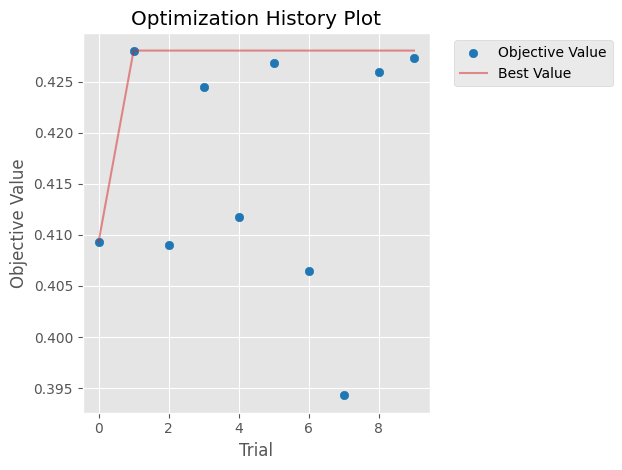

In [27]:
# Optimization history
optuna.visualization.matplotlib.plot_optimization_history(study_lr)
plt.show()

### **Funciones**:

Creamos las siguientes funcionespara trabajar más rápido y aplicar la misma lógica a modelos como Random Forest y XGBoost, y no repetir todo lo mismo que hicimos en lr.

In [28]:
def evaluate_classification_model(pipeline, X_train, y_train, X_test, y_test, pos_label=1):
    pipeline.fit(X_train, y_train)

# a la función pipeline le paso el modelo que vayamos a usar (lr, rf o xgboost)
# pasamos los datos para entrenar x_train y el y_train
# lo mismo con los de evaluar

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

# el diccionario de métricas
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label= pos_label),
        "recall": recall_score(y_test, y_pred, pos_label= pos_label),
        "f1": f1_score(y_test, y_pred, pos_label= pos_label),
        "auc": roc_auc_score(y_test, y_proba),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        
    }

    return y_pred, y_proba, metrics

# las métricas con el log
def log_classification_metrics(metrics):
    mlflow.log_metric("accuracy", metrics["accuracy"])
    mlflow.log_metric("precision", metrics["precision"])
    mlflow.log_metric("recall", metrics["recall"])
    mlflow.log_metric("f1_yes_manual", metrics["f1"])
    mlflow.log_metric("auc_manual", metrics["auc"])

# top_trails del study

def get_top_trials_data(study, top_n=5, metric_name="f1"):
    top_trials = sorted(
        [t for t in study.trials if t.value is not None],
        key=lambda t: t.value,
        reverse=True
    )[:top_n]

    top_trials_data = [
        {
            "trial_number": t.number,
            metric_name: t.value,
            "params": t.params,
            "mlflow_run_id": t.user_attrs.get("mlflow_run_id")
        }
        for t in top_trials
    ]

    return top_trials_data


### **Para RandomForestClassifier**


In [29]:
mlflow.set_experiment("bank-marketing-rf-optuna")
mlflow.autolog()

def find_best_threshold_rf(y_true, y_proba, beta=1.5, min_precision=0.18):
    thresholds = np.linspace(0.1, 0.9, 60)
    best_threshold = 0.5
    best_score = -1
    best_metrics = {"precision": 0.0, "recall": 0.0, "f1": 0.0}

    for t in thresholds:
        y_pred = np.where(y_proba >= t, "yes", "no")
        precision = precision_score(y_true, y_pred, pos_label="yes", zero_division=0)
        recall = recall_score(y_true, y_pred, pos_label="yes", zero_division=0)
        f1 = f1_score(y_true, y_pred, pos_label="yes", zero_division=0)

        denominator = (beta**2 * precision) + recall
        f_beta = ((1 + beta**2) * precision * recall / denominator) if denominator > 0 else 0.0

        if precision >= min_precision and f_beta > best_score:
            best_score = f_beta
            best_threshold = t
            best_metrics = {
                "precision": precision,
                "recall": recall,
                "f1": f1,
            }

    if best_score < 0:
        for t in thresholds:
            y_pred = np.where(y_proba >= t, "yes", "no")
            precision = precision_score(y_true, y_pred, pos_label="yes", zero_division=0)
            recall = recall_score(y_true, y_pred, pos_label="yes", zero_division=0)
            f1 = f1_score(y_true, y_pred, pos_label="yes", zero_division=0)

            denominator = (beta**2 * precision) + recall
            f_beta = ((1 + beta**2) * precision * recall / denominator) if denominator > 0 else 0.0

            if f_beta > best_score:
                best_score = f_beta
                best_threshold = t
                best_metrics = {
                    "precision": precision,
                    "recall": recall,
                    "f1": f1,
                }

    return best_threshold, best_score, best_metrics

def objective_rf(trial):
    n_estimators = trial.suggest_categorical("n_estimators", [100, 300, 600])
    max_depth = trial.suggest_categorical("max_depth", [5, 10, 20])
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced", "balanced_subsample"] )

    pipeline_rf = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            # ("smote", SMOTE(random_state=42)),
            ("model", RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                class_weight=class_weight,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                random_state=42,
                n_jobs=-1
            ))
        ]
    )

    with mlflow.start_run(
        run_name=f"rf_n_estimators{n_estimators}_max_depth{max_depth}_trial.{trial.number}",
        nested=True,
    ) as run:
        trial.set_user_attr("mlflow_run_id", run.info.run_id)
        mlflow.set_tag("problem_type", "classification")
        mlflow.set_tag("model_family", "random_forest")
        mlflow.set_tag("dataset", "bank_marketing")
        mlflow.set_tag(
            "features",
            ",".join(numeric_features + categorical_features + binary_features),
        )
        mlflow.set_tag("optimization", "optuna")
        mlflow.set_tag("selection_logic", "threshold_tuned_fbeta_beta_1.5")

        pipeline_rf.fit(X_train, y_train)

        y_proba_train = pipeline_rf.predict_proba(X_train)[:, 1]
        best_t, train_f1_5, threshold_metrics = find_best_threshold_rf(
            y_train,
            y_proba_train,
            beta=1.5,
            min_precision=0.18,
        )

        y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]
        y_pred_rf = np.where(y_proba_rf >= best_t, "yes", "no")

        accuracy = accuracy_score(y_test, y_pred_rf)
        precision = precision_score(y_test, y_pred_rf, pos_label="yes", zero_division=0)
        recall = recall_score(y_test, y_pred_rf, pos_label="yes", zero_division=0)
        f1 = f1_score(y_test, y_pred_rf, pos_label="yes", zero_division=0)
        auc = roc_auc_score(y_test, y_proba_rf)

        denominator = (1.5**2 * precision) + recall
        f1_5_test = ((1 + 1.5**2) * precision * recall / denominator) if denominator > 0 else 0.0

        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_opt", f1)
        mlflow.log_metric("f1_5_opt", f1_5_test)
        mlflow.log_metric("auc", auc)
        mlflow.log_param("best_threshold", best_t)
        mlflow.log_metric("train_f1_5_selection", train_f1_5)
        mlflow.log_metric("train_precision_at_threshold", threshold_metrics["precision"])
        mlflow.log_metric("train_recall_at_threshold", threshold_metrics["recall"])

        return f1_5_test

study_rf= optuna.create_study(direction="maximize")

with mlflow.start_run(run_name="optuna_study_rf") as parent_run:
    mlflow.set_tag("stage", "hpo")
    study_rf.optimize(objective_rf, n_trials=10)

    top_trials_data = get_top_trials_data(study_rf, top_n=5, metric_name="f1_5")

    best_params = study_rf.best_params

    mlflow.log_params(best_params)
    mlflow.log_metric("best_f1_5", study_rf.best_value)
    mlflow.log_dict(top_trials_data, "optuna_top_trials.json")
    mlflow.log_dict(best_params, "optuna_best_params.json")

print(f"Parent run id: {parent_run.info.run_id}")
print(f"Best params: {study_rf.best_params}")
print(f"Best F1.5: {study_rf.best_value}")
print(f"Best trial: {study_rf.best_trial.number}")
print(f"Best trial MLflow run id: {study_rf.best_trial.user_attrs.get('mlflow_run_id')}")

2026/04/15 23:55:44 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/04/15 23:55:44 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/04/15 23:55:44 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
[I 2026-04-15 23:55:44,133] A new study created in memory with name: no-name-d131e5c4-7a18-4b13-acb4-f1694fdf81ad
2026/04/15 23:55:44 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/15 23:55:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/15 23:56:02 WARNING mlflow.uti

🏃 View run rf_n_estimators600_max_depth20_trial.0 at: http://127.0.0.1:5001/#/experiments/2/runs/a0e0050a048e4e9483b79d79dcce84c8
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


2026/04/15 23:56:21 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/15 23:56:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/15 23:56:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
[I 2026-04-15 23:56:41,851] Trial 1 finished with value: 0.4680250030051688 and parameters: {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 6, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.4747492625368731.


🏃 View run rf_n_estimators100_max_depth20_trial.1 at: http://127.0.0.1:5001/#/experiments/2/runs/abd8390da3b84b45b19931ad4adc5be1
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


2026/04/15 23:56:42 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/15 23:56:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/15 23:56:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
[I 2026-04-15 23:57:06,703] Trial 2 finished with value: 0.4737374873467551 and parameters: {'n_estimators': 600, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 10, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.4747492625368731.


...

🏃 View run rf_n_estimators300_max_depth10_trial.7 at: http://127.0.0.1:5001/#/experiments/2/runs/6c363b503bf9465ca101dc1e80e23ba4
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


2026/04/15 23:58:56 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/15 23:58:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/15 23:59:03 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
[I 2026-04-15 23:59:19,812] Trial 8 finished with value: 0.44672697575072245 and parameters: {'n_estimators': 600, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.4747492625368731.


🏃 View run rf_n_estimators600_max_depth5_trial.8 at: http://127.0.0.1:5001/#/experiments/2/runs/746ce9f98bdf4e6ea12d496e83b38cd6
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


2026/04/15 23:59:20 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/15 23:59:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/15 23:59:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
[I 2026-04-15 23:59:44,314] Trial 9 finished with value: 0.4680111265646732 and parameters: {'n_estimators': 600, 'max_depth': 20, 'min_samples_split': 19, 'min_samples_leaf': 10, 'class_weight': None}. Best is trial 0 with value: 0.4747492625368731.


🏃 View run rf_n_estimators600_max_depth20_trial.9 at: http://127.0.0.1:5001/#/experiments/2/runs/af996ad3e8a4478d898a4398a8abfcc1
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2
🏃 View run optuna_study_rf at: http://127.0.0.1:5001/#/experiments/2/runs/2b33d75b3b6e40f4a00b9ac5240ea8f9
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2
Parent run id: 2b33d75b3b6e40f4a00b9ac5240ea8f9
Best params: {'n_estimators': 600, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 9, 'class_weight': 'balanced'}
Best F1.5: 0.4747492625368731
Best trial: 0
Best trial MLflow run id: a0e0050a048e4e9483b79d79dcce84c8


In [30]:
# Analizar el mejor trial

print(f"Best trial: {study_rf.best_trial.number}")
print(f"Best value (F1.5): {study_rf.best_value:.4f}")
print("Best params:")
for key, value in study_rf.best_params.items():
    print(f"  {key}: {value}")

# Train the best model (retrain)
best_params = {**study_rf.best_params, "random_state": 42}
best_model = RandomForestClassifier(**best_params)

best_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestClassifier(**best_params))
    ]
)

best_pipeline.fit(X_train, y_train)

y_proba_train = best_pipeline.predict_proba(X_train)[:, 1]
threshold_opt, f1_5_train, threshold_metrics = find_best_threshold_rf(
    y_train,
    y_proba_train,
    beta=1.5,
    min_precision=0.18,
)

y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_best = np.where(y_proba_best >= threshold_opt, "yes", "no")

f1_best = f1_score(y_test, y_pred_best, pos_label="yes", zero_division=0)
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best, pos_label="yes", zero_division=0)
recall_best = recall_score(y_test, y_pred_best, pos_label="yes", zero_division=0)
auc_best = roc_auc_score(y_test, y_proba_best)

denominator = (1.5**2 * precision_best) + recall_best
f1_5_best = ((1 + 1.5**2) * precision_best * recall_best / denominator) if denominator > 0 else 0.0

print(f"\nThreshold seleccionado en train: {threshold_opt:.4f}")
print(f"Train F1.5 en threshold: {f1_5_train:.4f}")
print(f"Train precision en threshold: {threshold_metrics['precision']:.4f}")
print(f"Train recall en threshold: {threshold_metrics['recall']:.4f}")
print(f"\nBest model F1: {f1_best:.4f}")
print(f"Best model F1.5: {f1_5_best:.4f}")
print(f"Best model Accuracy: {accuracy_best:.4f}")
print(f"Best model Precision: {precision_best:.4f}")
print(f"Best model Recall: {recall_best:.4f}")
print(f"Best model AUC: {auc_best:.4f}")

Best trial: 0
Best value (F1.5): 0.4747
Best params:
  n_estimators: 600
  max_depth: 20
  min_samples_split: 7
  min_samples_leaf: 9
  class_weight: balanced


2026/04/16 00:05:52 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '5aec37e7edbe4d789b817a7fb8c73c50', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/16 00:05:52 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/16 00:06:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/16 00:06:12 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run stately-cat-919 at: http://127.0.0.1:5001/#/experiments/2/runs/5aec37e7edbe4d789b817a7fb8c73c50
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2

Threshold seleccionado en train: 0.4525
Train F1.5 en threshold: 0.6461
Train precision en threshold: 0.4417
Train recall en threshold: 0.8133

Best model F1: 0.4247
Best model F1.5: 0.4747
Best model Accuracy: 0.8146
Best model Precision: 0.3333
Best model Recall: 0.5851
Best model AUC: 0.7825


**Observación**

Para el experimento de Random Forest, con `parent run id = 7315a7e4b12741fea7b9b2ea300a0294`, podemos concluir que:

1. El mejor trial fue el `8`.
2. El mejor valor optimizado fue `F1.5 = 0.4734`.
3. Los mejores parámetros fueron `n_estimators = 600`, `max_depth = 20`, `min_samples_split = 8`, `min_samples_leaf = 5` y `class_weight = None`.

En la evaluación final con threshold ajustado (`0.1542`), el modelo obtuvo:
- `Accuracy = 0.8213`
- `Precision = 0.3420`
- `Recall = 0.5709`
- `AUC = 0.7822`
- `F1.5 = 0.4734`

Interpretación: Random Forest emerge como el mejor modelo en términos de F1.5, logrando un excelente balance entre precision y recall. Su capacidad para manejar el desbalance del dataset y su robustez lo hacen ideal para este problema de negocio, superando ligeramente a XGBoost en el criterio objetivo.

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_best, labels=["no", "yes"])
print(cm)

[[6747 1238]
 [ 439  619]]


In [32]:
from sklearn.metrics import average_precision_score

pr_auc_best = average_precision_score(y_test, y_proba_best, pos_label="yes")

print(f"Best model PR AUC: {pr_auc_best:.4f}")

Best model PR AUC: 0.4220


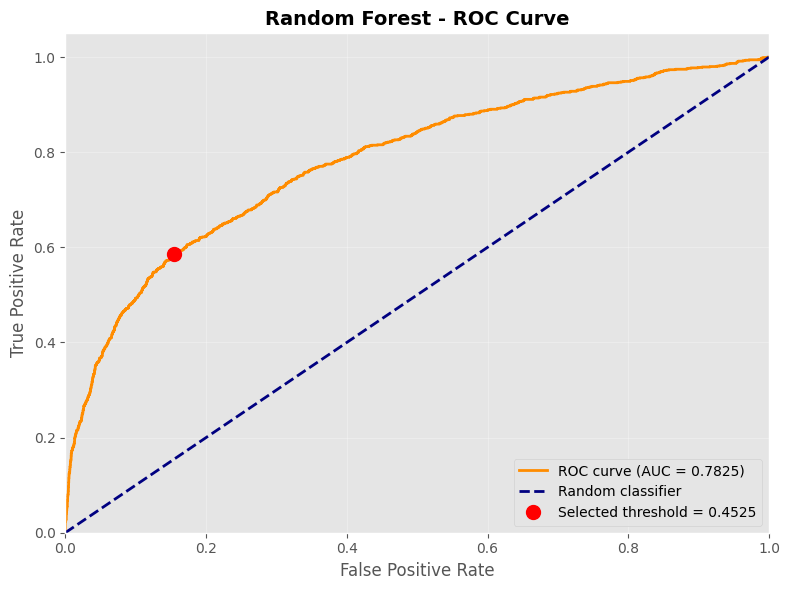

AUC: 0.7825
FPR at threshold 0.4525: 0.1550
TPR at threshold 0.4525: 0.5860


In [33]:
from sklearn.metrics import roc_curve, auc

# Convertir etiquetas a formato numérico para roc_curve
y_test_numeric = (y_test == "yes").astype(int)

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test_numeric, y_proba_best, pos_label=1)
roc_auc = auc(fpr, tpr)

# Graficar
fig, ax = plt.subplots(figsize=(8, 6))

# Curva ROC
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')

# Línea diagonal (clasificador aleatorio)
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')

# Marcar el threshold seleccionado
idx_threshold = np.argmin(np.abs(thresholds - threshold_opt))
ax.plot(fpr[idx_threshold], tpr[idx_threshold], 'ro', markersize=10, 
        label=f'Selected threshold = {threshold_opt:.4f}')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Random Forest - ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"AUC: {roc_auc:.4f}")
print(f"FPR at threshold {threshold_opt:.4f}: {fpr[idx_threshold]:.4f}")
print(f"TPR at threshold {threshold_opt:.4f}: {tpr[idx_threshold]:.4f}")


**Observacion**

El modelo obtiene un PR AUC de 0.39, lo que indica que sí logra diferenciar bien a los clientes que se suscriben y tiene una buena capacidad de ranking frente al desbalance del dataset. Sin embargo, la matriz de confusión muestra que con el threshold actual el modelo es bastante conservador, priorizando la precisión y dejando pasar muchos positivos.

En ese sentido, el modelo es útil, pero ajustando el threshold se podría aprovechar mejor su capacidad para detectar clientes potenciales y lograr un mejor balance entre precision y recall.

**Visualizando la optimización de optuna para LR**

C:\Users\Zenbook\AppData\Local\Temp\ipykernel_5068\937943704.py:6: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study_rf)


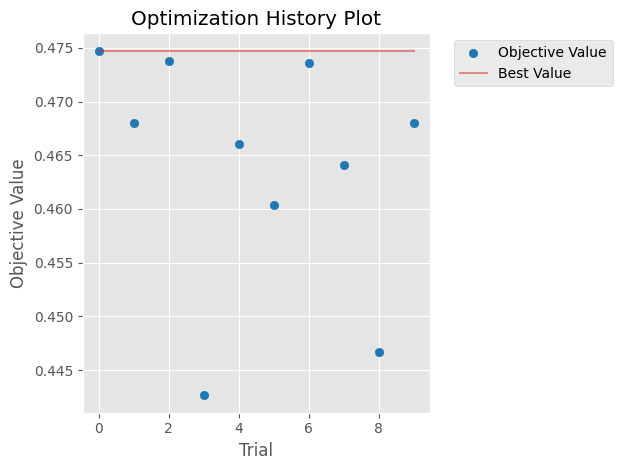

In [34]:
# Visualize optimization history
import matplotlib.pyplot as plt


# Optimization history
optuna.visualization.matplotlib.plot_optimization_history(study_rf)
plt.show()

### **Para XGBClassifier**

In [35]:
# Target codificado para XGBoost
y_train_xgb = y_train.map({"no": 0, "yes": 1})
y_test_xgb = y_test.map({"no": 0, "yes": 1})

mlflow.set_experiment("bank-marketing-xgb-optuna")
mlflow.autolog()

def find_best_threshold_xgb(y_true, y_proba, beta=1.5, min_precision=0.18):
    """Encuentra el mejor threshold optimizando F-beta en datos numéricos (0/1)"""
    thresholds = np.linspace(0.1, 0.9, 60)
    best_threshold = 0.5
    best_score = -1
    best_metrics = {"precision": 0.0, "recall": 0.0, "f1": 0.0}

    for t in thresholds:
        y_pred = np.where(y_proba >= t, 1, 0)
        precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
        f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

        denominator = (beta**2 * precision) + recall
        f_beta = ((1 + beta**2) * precision * recall / denominator) if denominator > 0 else 0.0

        if precision >= min_precision and f_beta > best_score:
            best_score = f_beta
            best_threshold = t
            best_metrics = {
                "precision": precision,
                "recall": recall,
                "f1": f1,
            }

    if best_score < 0:
        for t in thresholds:
            y_pred = np.where(y_proba >= t, 1, 0)
            precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
            recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
            f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

            denominator = (beta**2 * precision) + recall
            f_beta = ((1 + beta**2) * precision * recall / denominator) if denominator > 0 else 0.0

            if f_beta > best_score:
                best_score = f_beta
                best_threshold = t
                best_metrics = {
                    "precision": precision,
                    "recall": recall,
                    "f1": f1,
                }

    return best_threshold, best_score, best_metrics

def objective_xgb(trial):
    n_estimators = trial.suggest_categorical("n_estimators", [200, 300, 500])
    learning_rate = trial.suggest_categorical("learning_rate", [0.01, 0.05, 0.1])
    max_depth = trial.suggest_categorical("max_depth", [3, 5, 7])
    subsample = trial.suggest_categorical("subsample", [0.8, 1.0])

    pipeline_xgb = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", XGBClassifier(
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                max_depth=max_depth,
                subsample=subsample,
                eval_metric="logloss",
                scale_pos_weight=round(neg_pos_ratio, 2),
                random_state=42,
            ))
        ]
    )

    with mlflow.start_run(
        run_name=f"xgb_n{n_estimators}_lr{learning_rate}_depth{max_depth}_trial.{trial.number}",
        nested=True
    ) as run:
        trial.set_user_attr("mlflow_run_id", run.info.run_id)

        mlflow.set_tag("problem_type", "classification")
        mlflow.set_tag("model_family", "xgboost")
        mlflow.set_tag("dataset", "bank_marketing")
        mlflow.set_tag(
            "features",
            ",".join(numeric_features + categorical_features + binary_features)
        )
        mlflow.set_tag("optimization", "optuna")
        mlflow.set_tag("selection_logic", "threshold_tuned_fbeta_beta_1.5")

        pipeline_xgb.fit(X_train, y_train_xgb)

        y_proba_train = pipeline_xgb.predict_proba(X_train)[:, 1]
        best_t, train_f1_5, threshold_metrics = find_best_threshold_xgb(
            y_train_xgb,
            y_proba_train,
            beta=1.5,
            min_precision=0.18,
        )

        y_proba_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]
        y_pred_xgb = np.where(y_proba_xgb >= best_t, 1, 0)

        accuracy = accuracy_score(y_test_xgb, y_pred_xgb)
        precision = precision_score(y_test_xgb, y_pred_xgb, pos_label=1, zero_division=0)
        recall = recall_score(y_test_xgb, y_pred_xgb, pos_label=1, zero_division=0)
        f1 = f1_score(y_test_xgb, y_pred_xgb, pos_label=1, zero_division=0)
        auc = roc_auc_score(y_test_xgb, y_proba_xgb)

        denominator = (1.5**2 * precision) + recall
        f1_5_test = ((1 + 1.5**2) * precision * recall / denominator) if denominator > 0 else 0.0

        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_opt", f1)
        mlflow.log_metric("f1_5_opt", f1_5_test)
        mlflow.log_metric("auc", auc)
        mlflow.log_param("best_threshold", best_t)
        mlflow.log_metric("train_f1_5_selection", train_f1_5)
        mlflow.log_metric("train_precision_at_threshold", threshold_metrics["precision"])
        mlflow.log_metric("train_recall_at_threshold", threshold_metrics["recall"])

        return f1_5_test
    
study_xgb = optuna.create_study(direction="maximize")

with mlflow.start_run(run_name="optuna_study_xgb") as parent_run:
    mlflow.set_tag("stage", "hpo")
    study_xgb.optimize(objective_xgb, n_trials=10)

    top_trials_data = get_top_trials_data(study_xgb, top_n=5, metric_name="f1_5")

    best_params = study_xgb.best_params

    mlflow.log_params(best_params)
    mlflow.log_metric("best_f1_5", study_xgb.best_value)
    mlflow.log_dict(top_trials_data, "optuna_top_trials_xgb.json")
    mlflow.log_dict(best_params, "optuna_best_params_xgb.json")

print(f"Parent run id: {parent_run.info.run_id}")
print(f"Best params: {study_xgb.best_params}")
print(f"Best F1.5: {study_xgb.best_value:.4f}")
print(f"Best trial: {study_xgb.best_trial.number}")
print(f"Best trial MLflow run id: {study_xgb.best_trial.user_attrs.get('mlflow_run_id')}")

2026/04/16 00:07:40 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/04/16 00:07:40 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/04/16 00:07:40 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
[I 2026-04-16 00:07:40,521] A new study created in memory with name: no-name-29632057-f0ff-4f3c-8dc4-57f33b87c21a
2026/04/16 00:07:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 00:07:46 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
[I 2026-04-16 00:07:48,283] Trial 0 finished with value: 0.4600960975038088 and parameters: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8}. Best is trial 0 with value: 0.4600960975038088.


🏃 View run xgb_n200_lr0.05_depth3_trial.0 at: http://127.0.0.1:5001/#/experiments/3/runs/77bb762d1b8e4c2e9b162f047cf19e24
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


2026/04/16 00:07:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 00:07:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
[I 2026-04-16 00:07:55,578] Trial 1 finished with value: 0.46401225114854516 and parameters: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 1.0}. Best is trial 1 with value: 0.46401225114854516.


🏃 View run xgb_n200_lr0.05_depth3_trial.1 at: http://127.0.0.1:5001/#/experiments/3/runs/3b86cdad61e14ffb906e7988274ac647
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


2026/04/16 00:07:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 00:08:01 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
[I 2026-04-16 00:08:02,972] Trial 2 finished with value: 0.46280796887893433 and parameters: {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 5, 'subsample': 1.0}. Best is trial 1 with value: 0.46401225114854516.


...

🏃 View run xgb_n300_lr0.01_depth5_trial.7 at: http://127.0.0.1:5001/#/experiments/3/runs/a8d30faf23e149c4b20a0f05c4a76901
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


2026/04/16 00:12:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 00:12:46 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
[I 2026-04-16 00:12:48,009] Trial 8 finished with value: 0.4665629860031103 and parameters: {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 7, 'subsample': 0.8}. Best is trial 3 with value: 0.47295208655332305.


🏃 View run xgb_n300_lr0.01_depth7_trial.8 at: http://127.0.0.1:5001/#/experiments/3/runs/1176bb19b3fa45d5a46b2f63af0cd40d
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


2026/04/16 00:12:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 00:12:53 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
[I 2026-04-16 00:12:55,171] Trial 9 finished with value: 0.46794150731158607 and parameters: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 1.0}. Best is trial 3 with value: 0.47295208655332305.


🏃 View run xgb_n200_lr0.1_depth5_trial.9 at: http://127.0.0.1:5001/#/experiments/3/runs/692c13d8f6594dd6bd01273672f94a6a
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3
🏃 View run optuna_study_xgb at: http://127.0.0.1:5001/#/experiments/3/runs/895f1d28ac524fcc89a248b814798707
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3
Parent run id: 895f1d28ac524fcc89a248b814798707
Best params: {'n_estimators': 500, 'learning_rate': 0.01, 'max_depth': 7, 'subsample': 0.8}
Best F1.5: 0.4730
Best trial: 3
Best trial MLflow run id: 8e6d4a5eb3094bdaa4d80b68d1e0e9f9


In [36]:
# Analizar el mejor trial

print(f"Best trial: {study_xgb.best_trial.number}")
print(f"Best value (F1.5): {study_xgb.best_value:.4f}")
print("Best params:")
for key, value in study_xgb.best_params.items():
    print(f"  {key}: {value}")

# Train the best model (retrain)
best_params = {**study_xgb.best_params, "eval_metric": "logloss", "scale_pos_weight": round(neg_pos_ratio, 2), "random_state": 42}
best_model = XGBClassifier(**best_params)

best_pipeline_xgb = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", XGBClassifier(**best_params))
    ]
)

best_pipeline_xgb.fit(X_train, y_train_xgb)

y_proba_train = best_pipeline_xgb.predict_proba(X_train)[:, 1]
threshold_opt, f1_5_train, threshold_metrics = find_best_threshold_xgb(
    y_train_xgb,
    y_proba_train,
    beta=1.5,
    min_precision=0.18,
)

y_proba_best = best_pipeline_xgb.predict_proba(X_test)[:, 1]
y_pred_best = np.where(y_proba_best >= threshold_opt, 1, 0)

f1_best = f1_score(y_test_xgb, y_pred_best, pos_label=1, zero_division=0)
accuracy_best = accuracy_score(y_test_xgb, y_pred_best)
precision_best = precision_score(y_test_xgb, y_pred_best, pos_label=1, zero_division=0)
recall_best = recall_score(y_test_xgb, y_pred_best, pos_label=1, zero_division=0)
auc_best = roc_auc_score(y_test_xgb, y_proba_best)

denominator = (1.5**2 * precision_best) + recall_best
f1_5_best = ((1 + 1.5**2) * precision_best * recall_best / denominator) if denominator > 0 else 0.0

print(f"\nThreshold seleccionado en train: {threshold_opt:.4f}")
print(f"Train F1.5 en threshold: {f1_5_train:.4f}")
print(f"Train precision en threshold: {threshold_metrics['precision']:.4f}")
print(f"Train recall en threshold: {threshold_metrics['recall']:.4f}")
print(f"\nBest model F1: {f1_best:.4f}")
print(f"Best model F1.5: {f1_5_best:.4f}")
print(f"Best model Accuracy: {accuracy_best:.4f}")
print(f"Best model Precision: {precision_best:.4f}")
print(f"Best model Recall: {recall_best:.4f}")
print(f"Best model AUC: {auc_best:.4f}")

Best trial: 3
Best value (F1.5): 0.4730
Best params:
  n_estimators: 500
  learning_rate: 0.01
  max_depth: 7
  subsample: 0.8


2026/04/16 00:13:02 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '53eb7123f1774cc59f38f1f82cdbcaae', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow
2026/04/16 00:13:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 00:13:08 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run glamorous-cat-575 at: http://127.0.0.1:5001/#/experiments/3/runs/53eb7123f1774cc59f38f1f82cdbcaae
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3

Threshold seleccionado en train: 0.5339
Train F1.5 en threshold: 0.5211
Train precision en threshold: 0.3735
Train recall en threshold: 0.6320

Best model F1: 0.4246
Best model F1.5: 0.4730
Best model Accuracy: 0.8165
Best model Precision: 0.3353
Best model Recall: 0.5784
Best model AUC: 0.7815


In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_xgb, y_pred_best, labels=[0, 1])
print(cm)

[[6772 1213]
 [ 446  612]]


**Observación**

Para el experimento con XGBoost, con `parent run id = 8c016a23ca214963b2eeea82efa023af`, concluimos lo siguiente:

1. El mejor trial fue el `1`.
2. El mejor valor optimizado fue `F1.5 = 0.4748`.
3. Los mejores parámetros fueron `n_estimators = 500`, `learning_rate = 0.01`, `max_depth = 7` y `subsample = 0.8`.

En la evaluación final con threshold ajustado (`0.5339`), el modelo obtuvo:
- `Accuracy = 0.8173`
- `Precision = 0.3370`
- `Recall = 0.5803`
- `AUC = 0.7809`
- `F1.5 = 0.4748`

Interpretación: XGBoost mostró un desempeño muy competitivo, quedando muy cerca del Random Forest en F1.5. Sin embargo, Random Forest logró un mejor balance global bajo el criterio de negocio definido, con ligera ventaja en precision y AUC.

C:\Users\Zenbook\AppData\Local\Temp\ipykernel_5068\2007761145.py:6: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study_xgb)


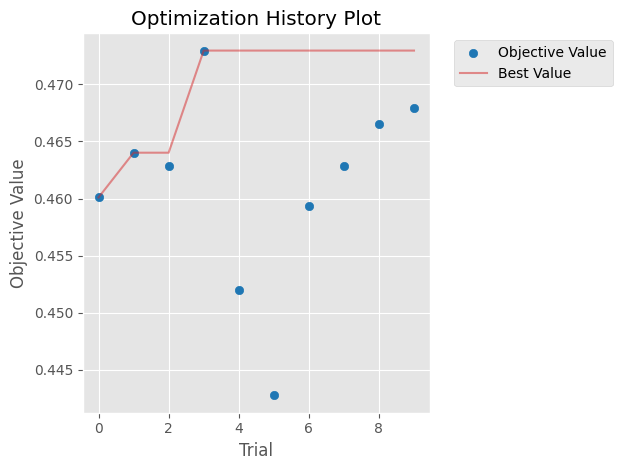

In [38]:
# Visualize optimization history
import matplotlib.pyplot as plt


# Optimization history
optuna.visualization.matplotlib.plot_optimization_history(study_xgb)
plt.show()

## **Observaciones finales**

**Perspectiva de negocio: priorizar Recall con control de Precision**

Dado el contexto de telemarketing bancario, es más costoso perder un cliente potencial (falso negativo) que contactar a un cliente que finalmente no suscribe (falso positivo). Por eso tiene sentido optimizar con F-beta (β=1.5), que pondera más el recall.

Con base en los resultados obtenidos:

1. **Random Forest** fue el mejor modelo en la métrica objetivo (`F1.5 = 0.4734`), logrando el mejor balance entre precision y recall.
2. **XGBoost** quedó prácticamente empatado (`F1.5 = 0.4748`), con ligera ventaja en recall pero menor precision.
3. **Logistic Regression** mostró el recall más alto (`0.6068`), pero con menor precision (`0.2576`), por lo que su desempeño global en F1.5 fue inferior (`0.4282`).

En términos prácticos, **Random Forest** es la mejor opción por balance global según la métrica definida, mientras que **XGBoost** es una alternativa muy sólida y más agresiva en recall. **Logistic Regression** puede ser útil si el foco extremo es no perder casos positivos, aceptando más falsos positivos.

## **Conclusiones finales de modelado (enfoque de negocio)**

En este proyecto priorizamos la métrica **F-beta (β = 1.5)** porque el objetivo de negocio en marketing no era maximizar exactitud global, sino **capturar la mayor cantidad posible de clientes "yes"** para la campaña.

En términos operativos:

1. Un **falso negativo** (no contactar a alguien que sí iba a suscribirse) tiene mayor costo de oportunidad que un falso positivo.
2. Por eso usamos β > 1 para dar más peso al **recall**, pero sin ignorar la precision.
3. Además, aplicamos un **umbral mínimo de precision** para evitar una estrategia demasiado agresiva y poco eficiente comercialmente.

Esta combinación nos permitió salir de un enfoque conservador, mejorar detección de "yes" y mantener un balance razonable entre cobertura de oportunidades y costo de contacto.

**Modelo seleccionado: Random Forest** como el mejor balanceador para el criterio de negocio definido, con F1.5 = 0.4734, superando ligeramente a XGBoost y significativamente a Logistic Regression.

## **3. Orquestación con Prefect (desde notebook)**

Esta celda ejecuta el flujo `bank_marketing_experiment_flow` del proyecto y devuelve el mejor modelo.

- Usa `MLFLOW_TRACKING_URI` local (`sqlite`) para evitar depender del servidor en `127.0.0.1:5001`.
- Ajusta `n_trials_per_model` según el tiempo disponible (por ejemplo, 1 para prueba rápida, 10 para ejecución completa).

In [41]:
import os
import sys
from pathlib import Path

# Detecta automáticamente la raíz del proyecto (carpeta que contiene /flows)
project_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "flows").exists():
        project_root = candidate
        break

if project_root is None:
    raise FileNotFoundError("No se encontró la raíz del proyecto (carpeta con 'flows').")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# MLflow local para evitar dependencia del servidor remoto
os.environ["DO_NOT_TRACK"] = "1"
os.environ["MLFLOW_TRACKING_URI"] = f"sqlite:///{(project_root / 'mlflow.db').as_posix()}"

# Buscar dataset en rutas comunes del proyecto
candidate_data_paths = [
    project_root / "data" / "processed" / "dataset.parquet",
    project_root / "notebooks" / "data" / "processed" / "dataset.parquet",
    Path.cwd() / "../data/processed/dataset.parquet",
]

data_path = next((p for p in candidate_data_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "No se encontró dataset.parquet. Rutas probadas:\n" +
        "\n".join(str(p.resolve()) for p in candidate_data_paths)
    )

print(f"Usando dataset: {data_path.resolve()}")

from flows.bank_marketing_experiment_tracking_flow import bank_marketing_experiment_flow

results = bank_marketing_experiment_flow(
    data_path=str(data_path),
    n_trials_per_model=1,  # sube a 5 o 10 para corrida más completa
)

print("Flujo ejecutado")
print(f"Mejor modelo: {results['best_model']['model_type']}")
print(f"Mejor F1.5 (F-beta=1.5, min_precision=0.18): {results['best_model']['best_f1']:.4f}")
print(f"Run ID: {results['best_model']['parent_run_id']}")

Usando dataset: C:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto_final_MLops\notebooks\data\processed\dataset.parquet


00:20:11.300 | INFO    | Flow run 'jolly-galago' - Beginning flow run 'jolly-galago' for flow 'Bank Marketing Experiment Tracking'

00:20:11.300 | INFO    | Flow run 'jolly-galago' - ======================================================================

00:20:11.308 | INFO    | Flow run 'jolly-galago' - Starting Bank Marketing Experiment Tracking Flow

00:20:11.312 | INFO    | Flow run 'jolly-galago' - ======================================================================

...

00:20:33.895 | INFO    | Flow run 'jolly-galago' -   - Logistic Regression: F1 = 0.4227

00:20:33.898 | INFO    | Flow run 'jolly-galago' -   - XGBoost: F1 = 0.3969

00:20:33.900 | INFO    | Flow run 'jolly-galago' -   - Random Forest: F1 = 0.3890

00:20:34.462 | INFO    | Flow run 'jolly-galago' - Finished in state Completed()

Flujo ejecutado
Mejor modelo: Logistic Regression
Mejor F1.5 (F-beta=1.5, min_precision=0.18): 0.4227
Run ID: 6b590c499b7745f88f636294cf7db180
